In [711]:
import pandas as pd
df = pd.read_excel("Data/Raw files/1.jan.xlsx")

In [712]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               351 non-null    object        
 1   order_date             351 non-null    datetime64[ns]
 2   customer_id            351 non-null    object        
 3   customer_name          351 non-null    object        
 4   age                    343 non-null    float64       
 5   gender                 351 non-null    object        
 6   region                 351 non-null    object        
 7   city                   351 non-null    object        
 8   product_category       351 non-null    object        
 9   product_name           351 non-null    object        
 10  quantity               341 non-null    float64       
 11  unit_price             351 non-null    float64       
 12  discount_pct           341 non-null    float64       
 13  sales

In [713]:
df.isnull().any()


order_id                 False
order_date               False
customer_id              False
customer_name            False
age                       True
gender                   False
region                   False
city                     False
product_category         False
product_name             False
quantity                  True
unit_price               False
discount_pct              True
sales_amount             False
profit                   False
shipping_cost            False
payment_method           False
customer_satisfaction     True
return_flag              False
order_status             False
days_to_ship              True
dtype: bool

In [714]:
df.isnull().sum()[df.isnull().sum()>0]

age                       8
quantity                 10
discount_pct             10
customer_satisfaction    18
days_to_ship             14
dtype: int64

In [715]:
df[df["age"].isnull()]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
42,ORD-00031,2020-01-12,CUST59076,Nisha Shah,NaN,MALE,West,Mumbai,Furniture,Bed Frame,...,5472.53,0.02,34892.59,10855.26,69.37,Net Banking,2.0,False,Delivered,3.0
82,ORD-00016,2020-01-06,CUST31154,Pooja Kapoor,NaN,Female,East,Patna,Clothing,Jeans,...,669.43,0.01,2618.73,710.90,82.42,Credit Card,4.0,False,Delivered,10.0
97,ORD-01669,2022-01-15,CUST66582,Deepa Singh,NaN,Female,South,Hyderabad,Electronics,Tablet,...,32073.99,0.13,216523.83,25075.11,53.93,Debit Card,1.0,False,Delivered,1.0
114,ORD-00834,2021-01-16,CUST47770,Nikhil Gupta,NaN,Other,South,Kochi,Clothing,Dress,...,2520.61,NaN,16226.61,4402.15,66.22,Credit Card,2.0,True,Returned,5.0
130,ORD-03412,2024-01-18,CUST88295,Deepa Reddy,NaN,Other,Central,Bhopal,Clothing,T-Shirt,...,1628.33,0.37,7092.35,2745.59,37.91,Credit Card,1.0,True,Returned,3.0
182,ORD-00081,2020-01-29,CUST60867,Deepa Sharma,NaN,MALE,Central,Indore,Electronics,Laptop,...,61637.72,0.29,298694.87,29985.13,20.79,EMI,4.0,False,Cancelled,5.0
233,ORD-00057,2020-01-21,CUST26450,Pooja Joshi,NaN,Other,South,Chennai,Groceries,Rice (5kg),...,104.12,0.32,491.80,20.12,81.05,Debit Card,4.0,False,Shipped,7.0
289,ORD-02592,2023-01-31,CUST27366,Sunita Kumar,NaN,Male,Central,Raipur,Beauty,Hair Oil,...,1780.34,0.22,11475.64,5187.94,61.88,Net Banking,4.0,True,Returned,1.0


In [716]:
(df["age"].isnull().sum() / len(df)) * 100


np.float64(2.2792022792022792)

In [717]:
df["age"].isnull().sum()

np.int64(8)

In [718]:
df["age"] = df["age"].fillna(
    df.groupby("gender")["age"].transform("median")
)

In [719]:
df[df["quantity"].isnull()]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
67,ORD-00069,2020-01-26,CUST27522,Deepa Chatterjee,24.0,Other,East,Bhubaneswar,Sports,Football,...,5929.85,0.00,4745.09,1518.74,78.48,Credit Card,5.0,False,Delivered,7.0
92,ORD-03427,2024-01-25,CUST72511,Sunita Gupta,34.0,Male,Central,Raipur,Groceries,Dal (1kg),...,470.22,0.07,370.80,28.04,65.41,Debit Card,2.0,False,Delivered,4.0
101,ORD-02574,2023-01-26,CUST72214,Nisha Nair,41.0,f,East,Kolkata,Groceries,Rice (5kg),...,462.27,0.29,302.37,27.61,74.43,EMI,4.0,False,Delivered,6.0
157,ORD-02558,2023-01-14,CUST46065,Ananya Rao,37.0,Other,West,Pune,Furniture,Desk,...,9906.71,0.34,6687.73,1816.22,51.63,EMI,3.0,False,Delivered,8.0
245,ORD-03423,2024-01-24,CUST37977,Deepa Mehta,33.0,Male,South,Hyderabad,Electronics,Smartwatch,...,76620.87,0.38,47511.85,5066.87,95.49,EMI,1.0,False,Delivered,2.0
247,ORD-00066,2020-01-25,CUST42917,Vikram Mehta,32.0,f,North,Amritsar,Sports,Tennis Racket,...,8113.16,0.23,4179.58,1043.14,76.45,Credit Card,1.0,True,Returned,4.0
286,ORD-02538,2023-01-06,CUST35874,Ananya Bose,30.0,Other,North,Delhi,Furniture,Bookshelf,...,12917.23,0.13,10872.27,2985.89,68.67,Cash on Delivery,2.0,False,Delivered,10.0
288,ORD-00867,2021-01-30,CUST45352,Rahul Das,46.0,Male,West,Pune,Beauty,Lipstick,...,1331.30,0.29,698.09,283.77,47.57,Cash on Delivery,2.0,False,Cancelled,6.0
296,ORD-02584,2023-01-28,CUST37196,Ritu Verma,31.0,Female,North,Amritsar,Books,Fiction Novel,...,1098.64,0.36,770.95,261.79,27.79,EMI,4.0,False,Delivered,9.0
305,ORD-03435,2024-01-29,CUST98330,Ananya Nair,65.0,Female,East,Bhubaneswar,Furniture,Bookshelf,...,10083.15,0.15,7994.96,1999.65,46.72,Net Banking,4.0,False,Delivered,1.0


In [720]:
df.loc[df["quantity"].isnull(), ["product_name", "quantity"]]

,product_name,quantity
67,Football,NaN
92,Dal (1kg),NaN
101,Rice (5kg),NaN
157,Desk,NaN
245,Smartwatch,NaN
247,Tennis Racket,NaN
286,Bookshelf,NaN
288,Lipstick,NaN
296,Fiction Novel,NaN
305,Bookshelf,NaN


In [721]:
df.loc[
    (df["quantity"].isnull()) & (df["product_name"] == "Bookshelf")
]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
286,ORD-02538,2023-01-06,CUST35874,Ananya Bose,30.0,Other,North,Delhi,Furniture,Bookshelf,...,12917.23,0.13,10872.27,2985.89,68.67,Cash on Delivery,2.0,False,Delivered,10.0
305,ORD-03435,2024-01-29,CUST98330,Ananya Nair,65.0,Female,East,Bhubaneswar,Furniture,Bookshelf,...,10083.15,0.15,7994.96,1999.65,46.72,Net Banking,4.0,False,Delivered,1.0


In [722]:
df[df["product_name"] == "Bookshelf"]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
81,ORD-02544,2023-01-09,CUST94242,Kavya Gupta,46.0,Male,North,Chandigarh,Furniture,Bookshelf,...,14759.75,0.17,87388.37,15358.82,24.99,EMI,NaN,False,Delivered,4.0
93,ORD-01641,2022-01-01,CUST87800,Rahul Patel,51.0,m,East,Bhubaneswar,Furniture,Bookshelf,...,27509.11,0.34,17323.10,3413.01,50.42,Credit Card,2.0,True,Returned,9.0
123,ORD-00873,2021-01-31,CUST74542,Arjun Gupta,18.0,Male,Central,Bhopal,Furniture,Bookshelf,...,10111.03,0.27,6692.45,2226.89,30.16,Debit Card,2.0,False,Delivered,4.0
177,ORD-00851,2021-01-23,CUST39419,Aditya Nair,48.0,Female,South,Kochi,Furniture,Bookshelf,...,6917.97,0.23,4191.15,1571.77,96.28,EMI,5.0,False,Delivered,5.0
184,ORD-00839,2021-01-19,CUST85913,Pooja Pillai,31.0,male,South,Chennai,Furniture,Bookshelf,...,2676.31,0.08,10381.04,3229.70,70.15,Net Banking,1.0,False,shipped,10.0
198,ORD-00813,2021-01-08,CUST99023,Nikhil Nair,29.0,Female,North,Amritsar,Furniture,Bookshelf,...,6110.59,0.37,8446.52,2197.30,23.22,Net Banking,3.0,False,Delivered,9.0
258,ORD-00843,2021-01-20,CUST07824,Priya Chatterjee,20.0,Female,West,Surat,Furniture,Bookshelf,...,7217.24,0.34,38701.84,9777.45,78.16,Net Banking,1.0,True,Returned,2.0
286,ORD-02538,2023-01-06,CUST35874,Ananya Bose,30.0,Other,North,Delhi,Furniture,Bookshelf,...,12917.23,0.13,10872.27,2985.89,68.67,Cash on Delivery,2.0,False,Delivered,10.0
305,ORD-03435,2024-01-29,CUST98330,Ananya Nair,65.0,Female,East,Bhubaneswar,Furniture,Bookshelf,...,10083.15,0.15,7994.96,1999.65,46.72,Net Banking,4.0,False,Delivered,1.0
308,ORD-02589,2023-01-30,CUST13119,Priya Bose,39.0,Other,West,Ahmedabad,Furniture,Bookshelf,...,8213.91,NaN,64071.92,12928.63,87.38,Net Banking,NaN,False,Delivered,9.0


In [723]:
df.loc[df["product_name"] == "Bookshelf", ["product_name", "quantity", "unit_price"]]

,product_name,quantity,unit_price
81,Bookshelf,7.0,14759.75
93,Bookshelf,1.0,27509.11
123,Bookshelf,1.0,10111.03
177,Bookshelf,1.0,6917.97
184,Bookshelf,6.0,2676.31
198,Bookshelf,3.0,6110.59
258,Bookshelf,10.0,7217.24
286,Bookshelf,NaN,12917.23
305,Bookshelf,NaN,10083.15
308,Bookshelf,8.0,8213.91


In [724]:
df.loc[
    df["product_name"] == "Bookshelf",
    ["product_name", "quantity", "unit_price"]
].sort_values("unit_price")

,product_name,quantity,unit_price
184,Bookshelf,6.0,2676.31
198,Bookshelf,3.0,6110.59
177,Bookshelf,1.0,6917.97
258,Bookshelf,10.0,7217.24
308,Bookshelf,8.0,8213.91
305,Bookshelf,NaN,10083.15
123,Bookshelf,1.0,10111.03
286,Bookshelf,NaN,12917.23
81,Bookshelf,7.0,14759.75
344,Bookshelf,6.0,20348.09


In [725]:
df["quantity"] = df["quantity"].fillna(
    df.groupby("product_name")["quantity"].transform("median"))
df["quantity"] = df["quantity"].astype(int)

In [726]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               351 non-null    object        
 1   order_date             351 non-null    datetime64[ns]
 2   customer_id            351 non-null    object        
 3   customer_name          351 non-null    object        
 4   age                    351 non-null    float64       
 5   gender                 351 non-null    object        
 6   region                 351 non-null    object        
 7   city                   351 non-null    object        
 8   product_category       351 non-null    object        
 9   product_name           351 non-null    object        
 10  quantity               351 non-null    int64         
 11  unit_price             351 non-null    float64       
 12  discount_pct           341 non-null    float64       
 13  sales

In [727]:
df.isnull().sum()[df.isnull().sum()>0]

discount_pct             10
customer_satisfaction    18
days_to_ship             14
dtype: int64

In [728]:
df["discount_pct"]

0      0.15
1      0.38
2       NaN
3      0.29
4      0.02
       ... 
346    0.12
347    0.32
348    0.16
349     NaN
350    0.22
Name: discount_pct, Length: 351, dtype: float64

In [729]:
df.loc[df["product_name"] == "T-Shirt",["product_name", "quantity", "discount_pct", "unit_price"]]

,product_name,quantity,discount_pct,unit_price
2,T-Shirt,9,NaN,590.14
53,T-Shirt,1,0.30,3433.94
60,T-Shirt,1,0.24,1100.40
130,T-Shirt,7,0.37,1628.33
134,T-Shirt,4,0.38,1975.84
303,T-Shirt,7,0.34,3456.76


In [730]:
df["discount_pct"] = df["discount_pct"].fillna(
    df.groupby(["product_name", "quantity"])["discount_pct"].transform("median"))

In [731]:
df["discount_pct"] = df["discount_pct"].fillna(df.groupby("product_name")["discount_pct"].transform("median"))


In [732]:
df.isnull().sum()[df.isnull().sum()>0]

customer_satisfaction    18
days_to_ship             14
dtype: int64

In [733]:
df["customer_satisfaction"] = df["customer_satisfaction"].fillna(df.groupby("product_name")
                                                                 ["customer_satisfaction"].transform("median"))

In [734]:
df.isnull().sum()[df.isnull().sum()>0]

days_to_ship    14
dtype: int64

In [735]:
df["customer_satisfaction"] = df["customer_satisfaction"].fillna(df.groupby("product_name")
                                                                 ["customer_satisfaction"].transform("median"))

In [736]:
df.isnull().sum()[df.isnull().sum()>0]

days_to_ship    14
dtype: int64

In [737]:
df["days_to_ship"] = df["days_to_ship"].fillna(df.groupby("product_name")
                                                                 ["days_to_ship"].transform("median"))

In [738]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

In [739]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               351 non-null    object        
 1   order_date             351 non-null    datetime64[ns]
 2   customer_id            351 non-null    object        
 3   customer_name          351 non-null    object        
 4   age                    351 non-null    float64       
 5   gender                 351 non-null    object        
 6   region                 351 non-null    object        
 7   city                   351 non-null    object        
 8   product_category       351 non-null    object        
 9   product_name           351 non-null    object        
 10  quantity               351 non-null    int64         
 11  unit_price             351 non-null    float64       
 12  discount_pct           351 non-null    float64       
 13  sales

In [740]:
df["gender"] = df["gender"].replace({"m" : "Male",
                                     "f" : "Female", 
                                     "M": "Male",
                                     "F" : "Female",
                                     "female" : "Female",
                                     "male" : "Male",
                                     "FEMALE" : "Female",
                                     "MALE" : "Male"})

In [741]:
df["gender"].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [742]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               351 non-null    object        
 1   order_date             351 non-null    datetime64[ns]
 2   customer_id            351 non-null    object        
 3   customer_name          351 non-null    object        
 4   age                    351 non-null    float64       
 5   gender                 351 non-null    object        
 6   region                 351 non-null    object        
 7   city                   351 non-null    object        
 8   product_category       351 non-null    object        
 9   product_name           351 non-null    object        
 10  quantity               351 non-null    int64         
 11  unit_price             351 non-null    float64       
 12  discount_pct           351 non-null    float64       
 13  sales

In [743]:
df["order_id"].nunique()

346

In [744]:
df[df["order_id"].duplicated()]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
265,ORD-03429,2024-01-26,CUST09088,Rohan Rao,36.0,Female,West,Ahmedabad,Beauty,Sunscreen,...,1843.94,0.31,13547.20,6188.12,63.02,EMI,3.0,False,Delivered,10.0
297,ORD-02585,2023-01-29,CUST32210,Meera Das,33.0,Male,South,Bangalore,Groceries,Cooking Oil,...,443.89,0.01,1152.72,75.70,66.88,Cash on Delivery,4.0,False,Delivered,9.0
313,ORD-00051,2020-01-20,CUST27973,Shreya Pillai,13.0,Male,South,Hyderabad,Beauty,Perfume,...,1952.59,0.14,6658.21,3867.94,38.17,Credit Card,1.0,False,Shipped,8.0
321,ORD-02524,2023-01-01,CUST02441,Sunita Bhat,54.0,Male,South,Bangalore,Sports,Cycle,...,6013.86,0.01,16119.22,3536.03,79.16,EMI,3.0,False,Shipped,6.0
348,ORD-00844,2021-01-20,CUST33448,Rahul Joshi,48.0,Other,South,Hyderabad,Clothing,Saree,...,2685.53,0.16,3463.77,1147.86,69.17,Cash on Delivery,2.0,True,Returned,6.0


In [745]:
df[df["order_id"].duplicated(keep=False)]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
38,ORD-00051,2020-01-20,CUST27973,Shreya Pillai,13.0,Male,South,Hyderabad,Beauty,Perfume,...,1952.59,0.14,6658.21,3867.94,38.17,Credit Card,1.0,False,Shipped,8.0
115,ORD-03429,2024-01-26,CUST09088,Rohan Rao,36.0,Female,West,Ahmedabad,Beauty,Sunscreen,...,1843.94,0.31,13547.20,6188.12,63.02,EMI,3.0,False,Delivered,10.0
166,ORD-00844,2021-01-20,CUST33448,Rahul Joshi,48.0,Other,South,Hyderabad,Clothing,Saree,...,2685.53,0.16,3463.77,1147.86,69.17,Cash on Delivery,2.0,True,Returned,6.0
220,ORD-02524,2023-01-01,CUST02441,Sunita Bhat,54.0,Male,South,Bangalore,Sports,Cycle,...,6013.86,0.01,16119.22,3536.03,79.16,EMI,3.0,False,Shipped,6.0
238,ORD-02585,2023-01-29,CUST32210,Meera Das,33.0,Male,South,Bangalore,Groceries,Cooking Oil,...,443.89,0.01,1152.72,75.70,66.88,Cash on Delivery,4.0,False,Delivered,9.0
265,ORD-03429,2024-01-26,CUST09088,Rohan Rao,36.0,Female,West,Ahmedabad,Beauty,Sunscreen,...,1843.94,0.31,13547.20,6188.12,63.02,EMI,3.0,False,Delivered,10.0
297,ORD-02585,2023-01-29,CUST32210,Meera Das,33.0,Male,South,Bangalore,Groceries,Cooking Oil,...,443.89,0.01,1152.72,75.70,66.88,Cash on Delivery,4.0,False,Delivered,9.0
313,ORD-00051,2020-01-20,CUST27973,Shreya Pillai,13.0,Male,South,Hyderabad,Beauty,Perfume,...,1952.59,0.14,6658.21,3867.94,38.17,Credit Card,1.0,False,Shipped,8.0
321,ORD-02524,2023-01-01,CUST02441,Sunita Bhat,54.0,Male,South,Bangalore,Sports,Cycle,...,6013.86,0.01,16119.22,3536.03,79.16,EMI,3.0,False,Shipped,6.0
348,ORD-00844,2021-01-20,CUST33448,Rahul Joshi,48.0,Other,South,Hyderabad,Clothing,Saree,...,2685.53,0.16,3463.77,1147.86,69.17,Cash on Delivery,2.0,True,Returned,6.0


In [746]:
df[df.duplicated(keep=False)]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
38,ORD-00051,2020-01-20,CUST27973,Shreya Pillai,13.0,Male,South,Hyderabad,Beauty,Perfume,...,1952.59,0.14,6658.21,3867.94,38.17,Credit Card,1.0,False,Shipped,8.0
115,ORD-03429,2024-01-26,CUST09088,Rohan Rao,36.0,Female,West,Ahmedabad,Beauty,Sunscreen,...,1843.94,0.31,13547.20,6188.12,63.02,EMI,3.0,False,Delivered,10.0
166,ORD-00844,2021-01-20,CUST33448,Rahul Joshi,48.0,Other,South,Hyderabad,Clothing,Saree,...,2685.53,0.16,3463.77,1147.86,69.17,Cash on Delivery,2.0,True,Returned,6.0
220,ORD-02524,2023-01-01,CUST02441,Sunita Bhat,54.0,Male,South,Bangalore,Sports,Cycle,...,6013.86,0.01,16119.22,3536.03,79.16,EMI,3.0,False,Shipped,6.0
238,ORD-02585,2023-01-29,CUST32210,Meera Das,33.0,Male,South,Bangalore,Groceries,Cooking Oil,...,443.89,0.01,1152.72,75.70,66.88,Cash on Delivery,4.0,False,Delivered,9.0
265,ORD-03429,2024-01-26,CUST09088,Rohan Rao,36.0,Female,West,Ahmedabad,Beauty,Sunscreen,...,1843.94,0.31,13547.20,6188.12,63.02,EMI,3.0,False,Delivered,10.0
297,ORD-02585,2023-01-29,CUST32210,Meera Das,33.0,Male,South,Bangalore,Groceries,Cooking Oil,...,443.89,0.01,1152.72,75.70,66.88,Cash on Delivery,4.0,False,Delivered,9.0
313,ORD-00051,2020-01-20,CUST27973,Shreya Pillai,13.0,Male,South,Hyderabad,Beauty,Perfume,...,1952.59,0.14,6658.21,3867.94,38.17,Credit Card,1.0,False,Shipped,8.0
321,ORD-02524,2023-01-01,CUST02441,Sunita Bhat,54.0,Male,South,Bangalore,Sports,Cycle,...,6013.86,0.01,16119.22,3536.03,79.16,EMI,3.0,False,Shipped,6.0
348,ORD-00844,2021-01-20,CUST33448,Rahul Joshi,48.0,Other,South,Hyderabad,Clothing,Saree,...,2685.53,0.16,3463.77,1147.86,69.17,Cash on Delivery,2.0,True,Returned,6.0


In [747]:
df.duplicated().sum()

np.int64(5)

In [748]:
df.drop_duplicates(inplace=True)


In [749]:
df["customer_id"].nunique()

345

In [750]:
df[df["customer_id"].duplicated(keep =False)]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
174,ORD-00045,2020-01-18,CUST28149,Amit Nair,35.0,Male,West,Ahmedabad,Beauty,Sunscreen,...,1072.98,0.33,2172.24,728.67,54.10,Net Banking,2.0,False,delivered,8.0
344,ORD-03387,2024-01-04,CUST28149,Sunita Kapoor,30.0,Female,West,Surat,Furniture,Bookshelf,...,20348.09,0.27,89448.76,23773.69,74.42,EMI,2.0,False,Cancelled,1.0


In [751]:
df.groupby("customer_id")["customer_name"].nunique()

customer_id
CUST00304    1
CUST00337    1
CUST01012    1
CUST01705    1
CUST02072    1
            ..
CUST98563    1
CUST98871    1
CUST99023    1
CUST99388    1
CUST99964    1
Name: customer_name, Length: 345, dtype: int64

In [752]:
df.groupby("customer_id")["customer_name"].nunique().loc[lambda x: x > 1]

customer_id
CUST28149    2
Name: customer_name, dtype: int64

In [753]:
name_conflict = (
    df.groupby("customer_id")["customer_name"]
      .transform("nunique") > 1
)
df["customer_name_conflict"] = name_conflict

In [754]:
df["customer_name_conflict"]

0      False
1      False
2      False
3      False
4      False
       ...  
345    False
346    False
347    False
349    False
350    False
Name: customer_name_conflict, Length: 346, dtype: bool

In [755]:
df["age"] = df["age"].astype(int)

In [756]:
df[df["age"] > 100]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,customer_name_conflict
14,ORD-00073,2020-01-28,CUST44662,Ananya Nair,999,Male,North,Delhi,Sports,Dumbbells,...,0.13,31129.56,7042.29,65.38,Credit Card,5.0,False,Delivered,4.0,False
310,ORD-02560,2023-01-14,CUST90788,Kavya Kapoor,999,Female,South,Kochi,Electronics,Tablet,...,0.00,17360314.17,2445648.43,82.19,EMI,1.0,False,Delivered,5.0,False


In [757]:
import numpy as np

df.loc[(df["age"] > 100) | (df["age"] < 1), "age"] = np.nan

In [758]:
df[df["quantity"] > 500].value_counts()

order_id   order_date  customer_id  customer_name  age   gender  region  city     product_category  product_name  quantity  unit_price  discount_pct  sales_amount  profit    shipping_cost  payment_method  customer_satisfaction  return_flag  order_status  days_to_ship  customer_name_conflict
ORD-00809  2021-01-05  CUST99388    Ritu Kapoor    33.0  Male    South   Chennai  Clothing          Jeans         999       3280.13     0.03          2586345.13    921794.6  83.69          EMI             1.0                    True         Returned      7.0           False                     1
Name: count, dtype: int64

In [759]:
df.loc[
    df["sales_amount"] > 1000000,
    ["product_name", "quantity", "unit_price", "discount_pct", "sales_amount"]
]

,product_name,quantity,unit_price,discount_pct,sales_amount
214,Jeans,999,3280.13,0.03,2586345.13
310,Tablet,999,18619.45,0.00,17360314.17


In [ ]:
mask = df["quantity"] > 500
mask.value_counts()

In [761]:
df.loc[df["quantity"]> 500, "quantity"] = np.nan

In [762]:
df["quantity"] = df["quantity"].fillna(df.groupby("product_name")["quantity"].transform("median"))
df["quantity"] = df["quantity"].astype(int)

In [763]:
df[["quantity","unit_price","sales_amount", "discount_pct", "profit"]]

,quantity,unit_price,sales_amount,discount_pct,profit
0,2,274.81,379.50,0.15,24.26
1,10,1492.28,9315.19,0.38,4336.31
2,9,590.14,4824.04,0.34,2277.40
3,3,34890.63,64727.53,0.29,18067.63
4,3,64874.09,177754.39,0.02,20320.94
...,...,...,...,...,...
345,8,381.64,2926.92,0.15,195.11
346,2,1132.17,1451.01,0.12,458.01
347,9,29868.65,117822.65,0.32,12480.50
349,3,14511.24,36886.86,0.16,8351.78


In [764]:
df["quantity"] = df["quantity"].astype(int)

df.loc[mask, "sales_amount"] = (
    df.loc[mask, "quantity"] *
    df.loc[mask, "unit_price"] *
    (1 - df.loc[mask, "discount_pct"])
    )

In [765]:
df.loc[
    df["sales_amount"] > 1000000,
    ["product_name", "quantity", "unit_price", "discount_pct", "sales_amount"]
]

,product_name,quantity,unit_price,discount_pct,sales_amount


In [766]:
df["product_name"].unique()

array(['Dal (1kg)', 'Cook Book', 'T-Shirt', 'Sofa', 'Headphones',
       'Smartwatch', 'Textbook', 'Tennis Racket', 'Hair Oil', 'Saree',
       'Laptop', 'Dumbbells', 'Lipstick', 'Fiction Novel', 'Yoga Mat',
       'Sunscreen', 'Flour', 'Bed Frame', 'Comic Book', 'Chair', 'Desk',
       'Self-Help Book', 'Football', 'Perfume', 'Kurta', 'Rice (5kg)',
       'Tea', 'Wardrobe', 'Jacket', 'Cricket Bat', 'Face Cream', 'Tablet',
       'Biography', 'Jeans', 'Camera', 'Cycle', 'Bookshelf', 'Shampoo',
       'Cooking Oil', 'Smartphone', 'Dress', 'Sugar'], dtype=object)

In [767]:
df["order_status"] = df["order_status"].replace({"delivered" :"Delivered",
                                                   "pending" : "Pending",
                                                   "shipped" : "Shipped",
                                                   "cancelled": "Cancelled"})

In [768]:
data = []
data.append(df)

In [769]:
finaldf = pd.concat(data, ignore_index=True)

In [770]:
finaldf["month"] = finaldf["order_date"].dt.month

In [771]:
monthly_sales = finaldf.groupby("month")["sales_amount"].sum()
monthly_sales

month
1    1.312381e+07
Name: sales_amount, dtype: float64

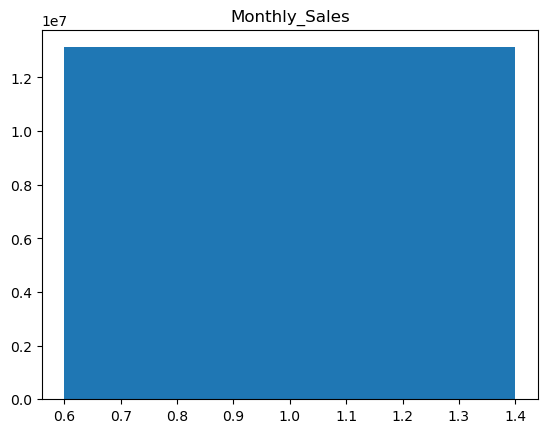

In [772]:
import matplotlib.pyplot as plt

plt.bar(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Monthly_Sales")

plt.show()

In [773]:
Regional_sales= finaldf.groupby("region")["sales_amount"].sum() 
Regional_sales

region
Central    2.095207e+06
East       2.681146e+06
North      3.113032e+06
South      2.611795e+06
West       2.622634e+06
Name: sales_amount, dtype: float64

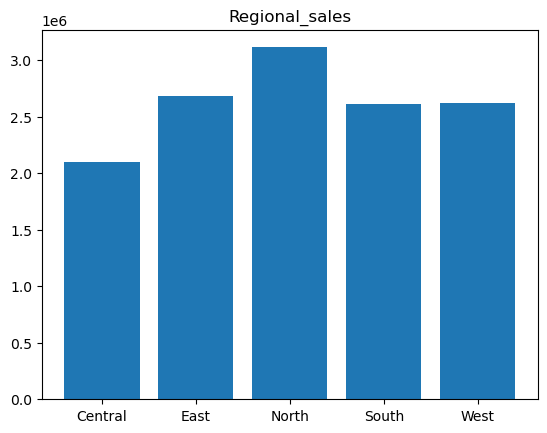

In [774]:
plt.bar(
    Regional_sales.index,
    Regional_sales.values
)

plt.title("Regional_sales")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

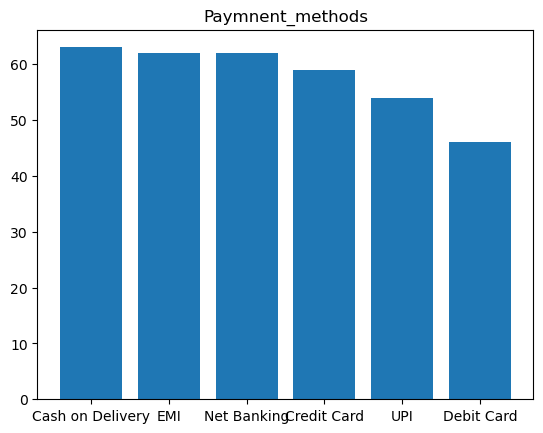

In [775]:
payments = finaldf["payment_method"].value_counts()

plt.bar(
    payments.index,
    payments.values
)
plt.title("Paymnent_methods")
plt.show

In [776]:
#age groups
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ["<18", "18-25", "26-35", "36-45", "46-60", "60+"]

In [777]:
finaldf["age_group"] = pd.cut(finaldf["age"], bins=bins, labels=labels)
finaldf.groupby(["age_group", "product_name"]).size()

C:\Users\Akshay\AppData\Local\Temp\ipykernel_11688\4269920602.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  finaldf.groupby(["age_group", "product_name"]).size()


age_group  product_name 
<18        Bed Frame        0
           Biography        1
           Bookshelf        1
           Camera           0
           Chair            0
                           ..
60+        Tea              0
           Tennis Racket    0
           Textbook         1
           Wardrobe         0
           Yoga Mat         0
Length: 252, dtype: int64

In [778]:
finaldf.groupby("age_group")["product_name"]\
  .agg(lambda x: x.value_counts().idxmax())

C:\Users\Akshay\AppData\Local\Temp\ipykernel_11688\678829851.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  finaldf.groupby("age_group")["product_name"]\


age_group
<18          Dumbbells
18-25           Laptop
26-35            Jeans
36-45    Tennis Racket
46-60            Cycle
60+           Lipstick
Name: product_name, dtype: object

In [779]:
product_max = finaldf.groupby("product_name")["sales_amount"] .max().sort_values(ascending=False)
product_max

product_name
Smartwatch        507797.13
Camera            386566.32
Laptop            381614.84
Smartphone        311838.93
Tablet            274146.04
Headphones        200569.38
Chair             165959.55
Sofa              135263.66
Desk              131999.09
Cricket Bat       107237.51
Tennis Racket     104587.68
Wardrobe          101055.44
Bed Frame          98718.08
Bookshelf          89448.76
Dumbbells          89199.08
Yoga Mat           85772.89
Football           66009.55
Cycle              43819.54
Jacket             25749.39
Jeans              25653.59
Dress              25017.30
Saree              21825.83
Kurta              20906.55
Hair Oil           19204.00
Face Cream         15979.96
T-Shirt            15504.08
Shampoo            13737.04
Sunscreen          13547.20
Lipstick           10532.18
Cook Book           9315.19
Textbook            8558.35
Perfume             6658.21
Biography           6120.48
Dal (1kg)           3726.88
Comic Book          3326.77
Self-He

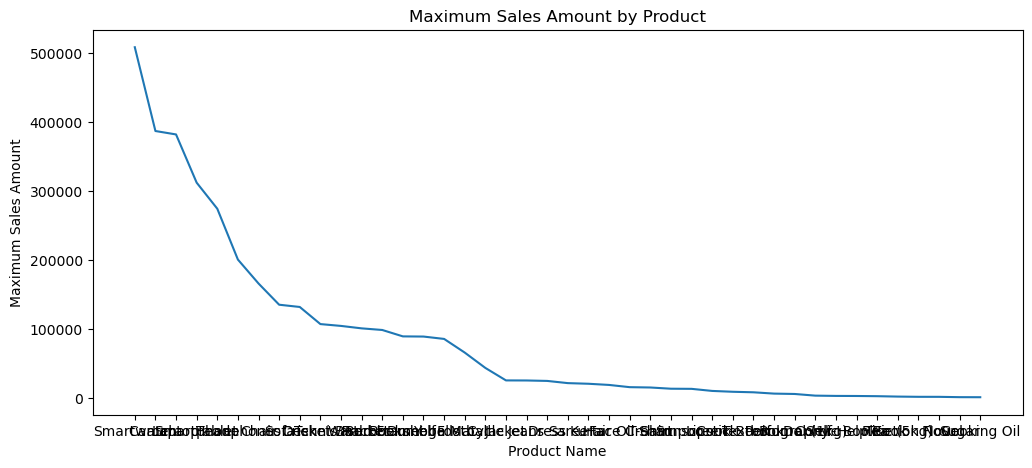

In [780]:
plt.figure(figsize=(12, 5))

plt.plot(product_max.index, product_max.values)

plt.title("Maximum Sales Amount by Product")
plt.xlabel("Product Name")
plt.ylabel("Maximum Sales Amount")

plt.show()

In [781]:
discount_max =  finaldf.groupby("product_name")["discount_pct"].max().sort_values(ascending = False)
discount_max

product_name
Bed Frame         0.40
Tennis Racket     0.40
Kurta             0.40
Football          0.40
Dress             0.40
Perfume           0.40
Lipstick          0.39
Saree             0.39
Desk              0.39
Hair Oil          0.39
Tablet            0.39
Cook Book         0.38
Smartwatch        0.38
Laptop            0.38
Jacket            0.38
Flour             0.38
Rice (5kg)        0.38
T-Shirt           0.38
Face Cream        0.37
Wardrobe          0.37
Shampoo           0.37
Bookshelf         0.37
Cycle             0.37
Dumbbells         0.37
Textbook          0.36
Sugar             0.36
Jeans             0.36
Fiction Novel     0.36
Cooking Oil       0.36
Camera            0.36
Biography         0.35
Sofa              0.35
Comic Book        0.34
Sunscreen         0.33
Cricket Bat       0.33
Yoga Mat          0.33
Chair             0.30
Headphones        0.29
Tea               0.27
Self-Help Book    0.26
Smartphone        0.26
Dal (1kg)         0.26
Name: discount_pct, d

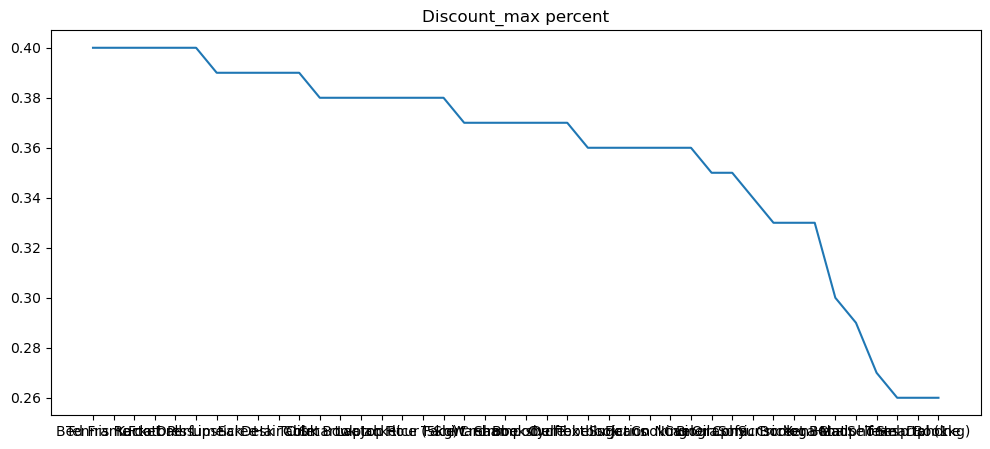

In [782]:
plt.figure(figsize=(12, 5))
plt.plot(
    discount_max.index,
    discount_max.values
)
plt.title("Discount_max percent")
plt.show()

In [783]:
orders_stat_info =  finaldf["order_status"].value_counts()
orders_stat_info


order_status
Delivered    203
Returned      63
Cancelled     34
Shipped       30
Pending       16
Name: count, dtype: int64

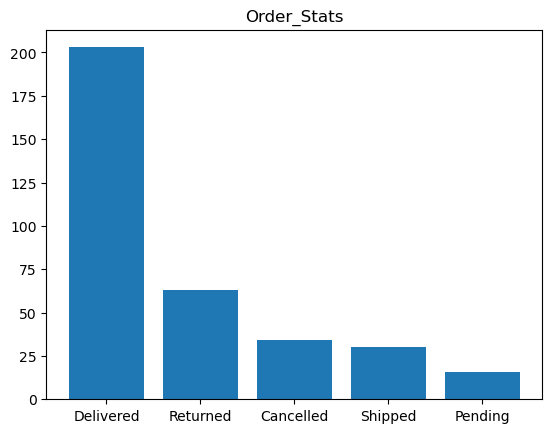

In [784]:
plt.bar(orders_stat_info.index, orders_stat_info.values)
plt.title("Order_Stats")
plt.show()

In [785]:

sales_by_gender = finaldf.groupby("gender")["sales_amount"].sum().sort_values(ascending = False)
sales_by_gender

gender
Female    5.066096e+06
Male      4.225769e+06
Other     3.831948e+06
Name: sales_amount, dtype: float64

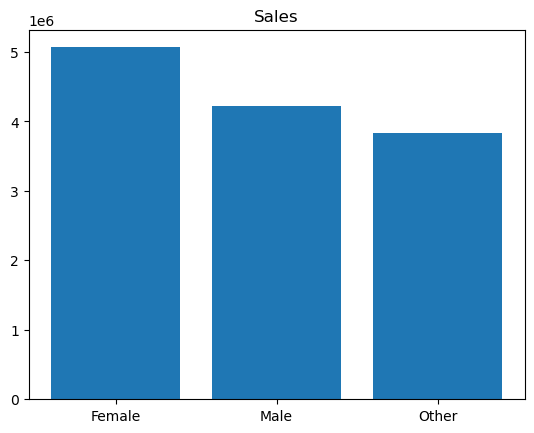

In [786]:
plt.bar(sales_by_gender.index,
        sales_by_gender.values)

plt.title("Sales")
plt.show()

In [787]:
total_sales = finaldf["sales_amount"].sum()
total_sales


np.float64(13123812.5066)

In [788]:
total_orders = finaldf["order_id"].nunique()
total_orders


346

In [789]:
average_discount = finaldf["discount_pct"].mean()
average_discount


np.float64(0.2029190751445087)

In [790]:
average_order = finaldf["sales_amount"].mean()
average_order 


np.float64(37930.09394971098)

In [791]:
highest_sale = finaldf["sales_amount"].max()
highest_sale


507797.13

In [792]:
finaldf

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,customer_name_conflict,month,age_group
0,ORD-01701,2022-01-28,CUST47772,Shreya Bose,14.0,Female,West,Ahmedabad,Groceries,Dal (1kg),...,24.26,46.69,EMI,4.0,False,Delivered,4.0,False,1,<18
1,ORD-03417,2024-01-21,CUST83946,Karan Bose,29.0,Female,West,Pune,Books,Cook Book,...,4336.31,66.67,Debit Card,3.0,True,Returned,8.0,False,1,26-35
2,ORD-02532,2023-01-04,CUST73360,Deepa Joshi,53.0,Male,South,Kochi,Clothing,T-Shirt,...,2277.40,79.19,EMI,1.0,False,Delivered,4.0,False,1,46-60
3,ORD-00049,2020-01-19,CUST43401,Sanjay Bose,21.0,Other,North,Delhi,Furniture,Sofa,...,18067.63,40.97,Net Banking,5.0,False,Shipped,3.0,False,1,18-25
4,ORD-03422,2024-01-23,CUST58923,Deepa Pillai,20.0,Male,East,Guwahati,Electronics,Headphones,...,20320.94,79.56,UPI,1.0,False,Delivered,7.0,False,1,18-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,ORD-03398,2024-01-12,CUST65122,Rahul Mehta,27.0,Other,West,Mumbai,Groceries,Tea,...,195.11,61.10,Net Banking,1.0,False,Shipped,1.0,False,1,26-35
342,ORD-00030,2020-01-11,CUST05185,Sanjay Rao,35.0,Other,East,Kolkata,Books,Fiction Novel,...,458.01,90.46,UPI,5.0,False,Cancelled,6.0,False,1,26-35
343,ORD-00012,2020-01-04,CUST61608,Karan Singh,21.0,Male,West,Ahmedabad,Electronics,Laptop,...,12480.50,51.76,UPI,1.0,False,Delivered,9.0,False,1,18-25
344,ORD-00060,2020-01-22,CUST06516,Pooja Das,41.0,Female,South,Bangalore,Sports,Cricket Bat,...,8351.78,63.58,EMI,3.0,False,Delivered,3.0,False,1,36-45
